# Equity Regression: Does Neighborhood Vulnerability Predict Service Delays?

**Research Question**: Is Census Tract socioeconomic status a statistically significant predictor of 311 service resolution time?

**Improvements over March baseline**:
1. **1.6M records** (vs 5K) — eliminates convergence and perfect separation issues
2. **Census Tract level** SVI (vs zip code) — reduces ecological fallacy
3. **Clustered standard errors** by tract — accounts for within-tract correlation
4. **Train/test split** — validates out-of-sample performance
5. **Proper service type controls** — using operational archetypes, not 175+ dummies

## 1. Build Operational Archetypes (K-Means on Service Types)

Instead of 175+ service type dummies, cluster service types into archetypes based on operational metrics: volume, mean resolution time, variance, and overdue rate.

In [2]:
# Compute operational metrics per service type
ops = df.groupby("type").agg(
    volume=("is_overdue", "count"),
    mean_res=("resolution_time_days", "mean"),
    var_res=("resolution_time_days", "var"),
    overdue_rate=("is_overdue", "mean")
).fillna(0)

# Filter low-volume types (< 50 tickets across 6 years = noise)
ops = ops[ops["volume"] >= 50]
print(f"Service types with 50+ tickets: {len(ops)}")

# Log-transform volume for clustering
ops["log_volume"] = np.log1p(ops["volume"])
cluster_features = ["log_volume", "mean_res", "var_res", "overdue_rate"]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(ops[cluster_features])

# K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
ops["cluster"] = kmeans.fit_predict(X_cluster)

# Display cluster profiles
cluster_profile = ops.groupby("cluster")[["volume", "mean_res", "overdue_rate"]].mean().round(2)
print("\nCluster profiles:")
print(cluster_profile)

# Name archetypes based on actual data (sorted by overdue_rate for stable naming)
cluster_rank = cluster_profile["overdue_rate"].sort_values()
archetype_map = {}
labels = ["Fast Resolution", "Routine", "Slow Queue", "Chronic Backlog"]
for label, cluster_id in zip(labels, cluster_rank.index):
    archetype_map[cluster_id] = label
    sample = ops[ops["cluster"] == cluster_id].nlargest(3, "volume").index.tolist()
    print(f"\n{label} (cluster {cluster_id}): {sample}")

Service types with 50+ tickets: 148

Cluster profiles:
           volume  mean_res  overdue_rate
cluster                                  
0          890.67   1125.49          0.81
1          720.95     87.84          0.17
2         2695.65    430.27          0.47
3        34619.73    105.41          0.20

Fast Resolution (cluster 1): ['Street Light Knock Downs', 'Parks General Request', 'Space Savers']

Routine (cluster 3): ['Parking Enforcement', 'Requests for Street Cleaning', 'Improper Storage of Trash (Barrels)']

Slow Queue (cluster 2): ['Sidewalk Repair (Make Safe)', 'Animal Generic Request', 'Unsatisfactory Living Conditions']

Chronic Backlog (cluster 0): ['Loud Parties/Music/People', 'Sidewalk Repair', 'StreetLight Pole WO']


In [3]:
# Map archetypes back to main dataframe
ops["archetype"] = ops["cluster"].map(archetype_map)
df["archetype"] = df["type"].map(ops["archetype"]).fillna("Rare/Unclassified")

print("Archetype distribution:")
print(df["archetype"].value_counts())
print(f"\nOverdue rate by archetype:")
print(df.groupby("archetype")["is_overdue"].mean().sort_values().round(4))

Archetype distribution:
archetype
Routine              1419409
Slow Queue            145565
Fast Resolution        29559
Chronic Backlog        10688
Rare/Unclassified        632
Name: count, dtype: int64

Overdue rate by archetype:
archetype
Routine              0.1515
Fast Resolution      0.1554
Rare/Unclassified    0.3940
Slow Queue           0.4597
Chronic Backlog      0.8417
Name: is_overdue, dtype: float64


## 1.5 VIF Diagnostic — Multicollinearity Among SVI Features (Tutor #2)

SVI variables are known to correlate (e.g. poverty ↔ no-vehicle ↔ minority), which inflates standard errors and makes p-values unreliable. We compute VIF on the raw SVI feature set and **iteratively drop the highest-VIF feature until all remaining VIFs ≤ 5**. The reduced `svi_features` list is used for the regression below.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# --- Paths (single source of truth: Step3. April_v1.1/data/) ---
DATA_DIR    = Path(r"D:\Pycharm\PycharmProjects\CS506_Final_Project\Step3. April_v1.1\data")
FIGURES_DIR = Path(r"D:\Pycharm\PycharmProjects\CS506_Final_Project\Step3. April_v1.1\figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Reference "now" — matches the cutoff used in spatial_join.ipynb
REFERENCE_DATE = pd.Timestamp("2026-04-08", tz="UTC")

df = pd.read_parquet(DATA_DIR / "boston_311_with_svi.parquet")
df["open_dt"] = pd.to_datetime(df["open_dt"], utc=True)
print(f"Raw records: {len(df):,} | Tracts: {df['GEOID'].nunique()}")
print(f"Overdue rate (raw): {df['is_overdue'].mean():.2%} | Censored (still open): {df['is_censored'].mean():.2%}")

# --- Tutor Feedback #1: hard right-censoring cutoff ---
# Tickets opened within the last 30 days have an indeterminate overdue label
# (still open AND <30 days old means they could still cross the threshold).
# Drop them before modeling so the target is fully observed.
cutoff = REFERENCE_DATE - pd.Timedelta(days=30)
n_before = len(df)
df = df[df["open_dt"] < cutoff].copy()
print(f"\n[Right-censor] open_dt < {cutoff.date()}: kept {len(df):,} / {n_before:,} "
      f"({len(df)/n_before:.1%}). Dropped {n_before-len(df):,} indeterminate tickets.")
print(f"Overdue rate after cutoff: {df['is_overdue'].mean():.2%}")

In [4]:
svi_candidates = ["EP_POV150", "EP_UNEMP", "EP_NOHSDP", "EP_LIMENG", "EP_MINRTY", "EP_NOVEH"]

df_vif = df.dropna(subset=svi_candidates).copy()

def compute_vif(features, data):
    X_vif = sm.add_constant(data[features])
    return pd.Series(
        [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(features))],
        index=features,
    )

print("Initial VIF (all SVI candidates):")
print(compute_vif(svi_candidates, df_vif).round(2).sort_values(ascending=False))

# Iteratively drop the single highest-VIF feature until all remaining ≤5
dropped = []
svi_features = svi_candidates.copy()
while len(svi_features) >= 2:
    vif = compute_vif(svi_features, df_vif)
    if vif.max() <= 5:
        break
    worst = vif.idxmax()
    print(f"  Drop '{worst}' (VIF={vif[worst]:.2f})")
    dropped.append(worst)
    svi_features.remove(worst)

print("\nFinal VIF (all ≤5):")
print(compute_vif(svi_features, df_vif).round(2))
print(f"\nRetained SVI features ({len(svi_features)}): {svi_features}")
print(f"Dropped ({len(dropped)}): {dropped}")

# Pairwise correlation (for intuition) on the retained set
corr = df_vif[svi_features].corr().round(2)
print("\nCorrelation matrix (retained):")
print(corr)

Initial VIF (all SVI candidates):
EP_NOHSDP    4.75
EP_POV150    3.33
EP_LIMENG    3.16
EP_MINRTY    3.14
EP_UNEMP     1.87
EP_NOVEH     1.55
dtype: float64

Final VIF (all ≤5):
EP_POV150    3.33
EP_UNEMP     1.87
EP_NOHSDP    4.75
EP_LIMENG    3.16
EP_MINRTY    3.14
EP_NOVEH     1.55
dtype: float64

Retained SVI features (6): ['EP_POV150', 'EP_UNEMP', 'EP_NOHSDP', 'EP_LIMENG', 'EP_MINRTY', 'EP_NOVEH']
Dropped (0): []

Correlation matrix (retained):
           EP_POV150  EP_UNEMP  EP_NOHSDP  EP_LIMENG  EP_MINRTY  EP_NOVEH
EP_POV150       1.00      0.63       0.63       0.55       0.67      0.47
EP_UNEMP        0.63      1.00       0.54       0.44       0.61      0.16
EP_NOHSDP       0.63      0.54       1.00       0.82       0.77      0.08
EP_LIMENG       0.55      0.44       0.82       1.00       0.63      0.12
EP_MINRTY       0.67      0.61       0.77       0.63       1.00      0.06
EP_NOVEH        0.47      0.16       0.08       0.12       0.06      1.00


## 2. Prepare Regression Data

- SVI features (continuous): EP_POV150, EP_UNEMP, EP_NOHSDP, EP_LIMENG, EP_MINRTY, EP_NOVEH
- Controls: archetype dummies, report source dummies
- Target: `is_overdue` (binary)
- Clustered standard errors by Census Tract (`GEOID`)

In [5]:
# svi_features was finalized by the VIF pruning step above.

# Prepare modeling dataframe
df_reg = df.dropna(subset=svi_features + ["is_overdue", "archetype", "source"]).copy()

# Archetype dummies (drop "Fast Resolution" as baseline)
arch_dummies = pd.get_dummies(df_reg["archetype"], prefix="Arch", drop_first=False)
arch_dummies = arch_dummies.drop(columns=[c for c in arch_dummies.columns if "Fast" in c], errors="ignore")

# Source dummies: keep top 4, rest = Other
top_sources = df_reg["source"].value_counts().nlargest(4).index
df_reg["source_group"] = np.where(df_reg["source"].isin(top_sources), df_reg["source"], "Other")
src_dummies = pd.get_dummies(df_reg["source_group"], prefix="Src", drop_first=True)

# Assemble feature matrix
X = pd.concat([df_reg[svi_features], arch_dummies, src_dummies], axis=1).astype(float)
X = sm.add_constant(X)
y = df_reg["is_overdue"].astype(float)
groups = df_reg["GEOID"]  # for clustered SE

print(f"Modeling data: {len(X):,} records, {X.shape[1]} features ({len(svi_features)} SVI after VIF pruning)")
print(f"Overdue rate: {y.mean():.2%}")
print(f"Clusters (tracts): {groups.nunique()}")

Modeling data: 1,589,301 records, 15 features (6 SVI after VIF pruning)
Overdue rate: 18.31%
Clusters (tracts): 314


## 3. Train/Test Split + Logistic Regression with Clustered SE

We split 80/20 stratified by `is_overdue`, fit on train, and use clustered standard errors to account for within-tract correlation.

In [6]:
# Train/test split (stratified)
X_train, X_test, y_train, y_test, grp_train, grp_test = train_test_split(
    X, y, groups, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train overdue rate: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

# Fit logistic regression with clustered standard errors
logit = sm.Logit(y_train, X_train)
result = logit.fit(maxiter=200, disp=False)

# Re-fit with clustered SE
result_clustered = logit.fit(
    maxiter=200, disp=False,
    cov_type="cluster", cov_kwds={"groups": grp_train}
)
print(f"\nConverged: {result.mle_retvals['converged']}")
print(result_clustered.summary())

Train: 1,271,440  |  Test: 317,861
Train overdue rate: 18.31%  |  Test: 18.31%

Converged: True
                           Logit Regression Results                           
Dep. Variable:             is_overdue   No. Observations:              1271440
Model:                          Logit   Df Residuals:                  1271425
Method:                           MLE   Df Model:                           14
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.08821
Time:                        15:51:03   Log-Likelihood:            -5.5191e+05
converged:                       True   LL-Null:                   -6.0531e+05
Covariance Type:              cluster   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1.3672      0.086    -15.942      0.000      -1.535      -1.199

## 4. Odds Ratios — Quantifying the Equity Gap

Exponentiated coefficients show the multiplicative change in odds of being overdue for each 1 percentage-point increase in a vulnerability measure.

Odds Ratios (Clustered SE):
           Odds Ratio  CI Lower  CI Upper  p-value  Significant
EP_POV150      0.9975    0.9920    1.0030   0.3756        False
EP_UNEMP       1.0003    0.9890    1.0118   0.9521        False
EP_NOHSDP      0.9938    0.9850    1.0027   0.1714        False
EP_LIMENG      1.0006    0.9921    1.0092   0.8909        False
EP_MINRTY      1.0028    1.0005    1.0050   0.0181         True
EP_NOVEH       0.9983    0.9943    1.0023   0.4061        False


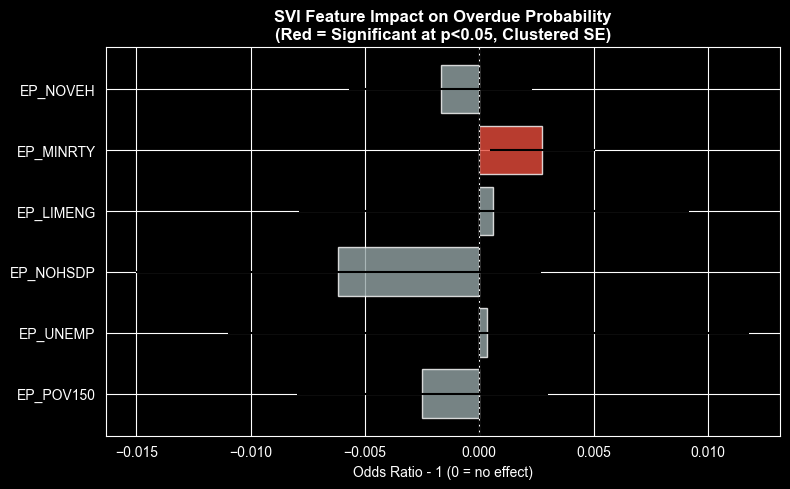

In [7]:
# Odds ratios with clustered CIs for SVI features only
params = result_clustered.params[svi_features]
ci = result_clustered.conf_int().loc[svi_features]
pvalues = result_clustered.pvalues[svi_features]

odds_df = pd.DataFrame({
    "Odds Ratio": np.exp(params),
    "CI Lower": np.exp(ci[0]),
    "CI Upper": np.exp(ci[1]),
    "p-value": pvalues,
    "Significant": pvalues < 0.05
})
print("Odds Ratios (Clustered SE):")
print(odds_df.round(4))

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(odds_df))
ax.barh(y_pos, odds_df["Odds Ratio"] - 1, xerr=[
    odds_df["Odds Ratio"] - odds_df["CI Lower"],
    odds_df["CI Upper"] - odds_df["Odds Ratio"]
], color=["#e74c3c" if s else "#95a5a6" for s in odds_df["Significant"]], alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(odds_df.index)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds Ratio - 1 (0 = no effect)")
ax.set_title("SVI Feature Impact on Overdue Probability\n(Red = Significant at p<0.05, Clustered SE)", fontweight="bold")
fig.tight_layout()
plt.savefig(FIGURES_DIR / "odds_ratios_clustered.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Out-of-Sample Evaluation (Test Set)

Confusion matrix and classification report on held-out test data. We use 0.5 threshold initially; threshold tuning for Recall optimization will be done in the dedicated classifier notebook (Task #6).

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

     On Time       0.83      0.99      0.90    259657
     Overdue       0.64      0.10      0.18     58204

    accuracy                           0.83    317861
   macro avg       0.74      0.55      0.54    317861
weighted avg       0.80      0.83      0.77    317861



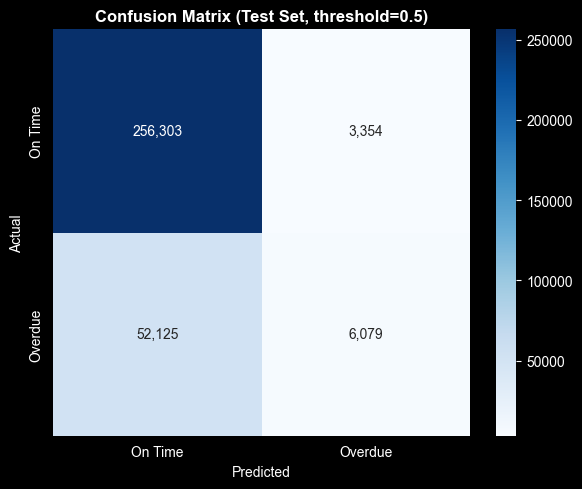

In [8]:
# Predict on test set
y_pred_prob = result.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Classification Report (threshold=0.5):")
print(classification_report(y_test, y_pred, target_names=["On Time", "Overdue"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["On Time", "Overdue"],
            yticklabels=["On Time", "Overdue"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Test Set, threshold=0.5)", fontweight="bold")
fig.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Summary of Key Findings

In [9]:
# Print summary for easy reference
print("=" * 60)
print("EQUITY REGRESSION SUMMARY (post-tutor-feedback)")
print("=" * 60)
print(f"Right-censor cutoff: open_dt < {cutoff.date()} applied")
print(f"VIF pruning dropped: {dropped or '(none)'}")
print(f"Retained SVI features: {svi_features}")
print(f"Dataset: {len(X):,} records, {groups.nunique()} Census Tracts")
print(f"Train/Test: {len(X_train):,} / {len(X_test):,}")
print(f"Model converged: {result.mle_retvals['converged']}")
print(f"Pseudo R\u00b2: {result.prsquared:.4f}")
print()
print("Significant SVI predictors (clustered SE, p<0.05):")
any_sig = False
for feat in svi_features:
    p = result_clustered.pvalues[feat]
    or_val = np.exp(result_clustered.params[feat])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    if p < 0.05:
        any_sig = True
        direction = "increases" if or_val > 1 else "decreases"
        print(f"  {feat}: OR={or_val:.4f} (p={p:.4f}) {sig}")
        print(f"    \u2192 1pp increase in {feat} {direction} overdue odds by {abs(or_val-1)*100:.2f}%")
if not any_sig:
    print("  (none after right-censoring + VIF pruning)")
print()
print("Controls: archetype dummies + source dummies")
print("Standard errors: clustered by Census Tract")

EQUITY REGRESSION SUMMARY (post-tutor-feedback)
Right-censor cutoff: open_dt < 2026-03-09 applied
VIF pruning dropped: (none)
Retained SVI features: ['EP_POV150', 'EP_UNEMP', 'EP_NOHSDP', 'EP_LIMENG', 'EP_MINRTY', 'EP_NOVEH']
Dataset: 1,589,301 records, 314 Census Tracts
Train/Test: 1,271,440 / 317,861
Model converged: True
Pseudo R²: 0.0882

Significant SVI predictors (clustered SE, p<0.05):
  EP_MINRTY: OR=1.0028 (p=0.0181) *
    → 1pp increase in EP_MINRTY increases overdue odds by 0.28%

Controls: archetype dummies + source dummies
Standard errors: clustered by Census Tract
